# Super-Bowl-Advertiser — a quantitative teardown 🔬
### Abnormal-return event windows on a Super Bowl advertiser table · a drift leg vs zero · a Welch *t* + placebo randomization null · the costed ad-calendar basket · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Big-ad signal?: Not supported](https://img.shields.io/badge/Big--ad_signal%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We treat the folklore as a **one-legged event-study hypothesis** — a positive post-game **drift** for advertisers — and confront it with the **sample size** and with **survivorship**. The decisive objects are a cross-section of ~32 abnormal-return events and a placebo null sized to that count.

> ⚠️ **Data + survivorship note.** The advertiser table is hardcoded and transparent (~32 real listed advertiser-years, 2015–2024); the priced tape is **survivor-biased** — the loudest advertisers in history (Pets.com, Computer.com, Kozmo.com, the dot-com class of 2000) **went bust** and leave no series, biasing the drift *up* (named on the Signal axis). Real data: yfinance daily adjusted closes. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from super_bowl_advertiser import data, strategy as st

HAVE_REAL = data.have_real()
B = data.load_real() if HAVE_REAL else None
EV = st.collect_events(B) if HAVE_REAL else None
print("real advertiser-tape cache present:", HAVE_REAL,
      "| events priced:", (0 if EV is None else len(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 32, 'n_delisted': 11, 'n_priced': 32, 'fp': 'fc267dcab645', 'monday': (-0.33, 41, -0.83), 'drift': (0.39, 47, 0.31, 0.637), 'hold': (1.2, 50, 0.6, 0.471), 'eras': [('2015-17', 3, 2.79, 6.66), ('2019-21', 12, -1.32, 3.66), ('2022-24', 17, 1.17, -1.49)], 'robust': [('3/10', 32, 0.76, 0.93, -0.31, -0.2), ('5/20', 32, 0.39, 0.31, 1.2, 0.6), ('10/40', 32, 1.71, 1.13, -2.92, -1.02)], 'cost': {'gross_drift': 0.39, 'net_drift': 0.19, 'gross_hold': 1.59, 'net_hold': 1.39}, 'syn': [(0.0, 32, -0.03, -0.05, 0.2, 0.09), (0.1, 32, 10.48, 13.23, 0.2, 0.09)], 'drift_std': 0.0719}


real advertiser-tape cache present: True | events priced: 32


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | drift **+0.4%** (Welch **t = 0.31**, placebo **p = 0.64**), win-rate **47%** (< 50%); Monday reaction **-0.3%** (**t = -0.83**, *negative*). Dead-center in the luck cloud. |
| **Tradability** | `MIRAGE` | ad basket = **+0.4% gross**, **+0.2% net** of 2 large-cap crossings over 5 days — a rounding error inside its own SE. |
| **Big-ad signal?** | `NOT SUPPORTED` | Fehle-Tsyplakov-Zdorovtsov (2005) found it on a 2000–04 sample; on a modern ~32-event survivor tape the drift is noise and the memorable 'ads pay' cases **delisted**. |

> 💡 In plain words: a much-cited 2005 result and a famous sock puppet have kept the 'buy the buzz' idea alive, but on the names we can still price the post-game drift is indistinguishable from three-dozen random February weeks — and the day-one move is *negative*.

## 1 · The claim, steelmanned

Let $r^{i}_{[a,b]}$ be advertiser $i$'s cumulative **abnormal** return (in excess of SPY) over trading-day offsets $[a,b]$ relative to the Monday after its Super Bowl (entry lagged one day). Define a **drift** leg $D_i = r^{i}_{[+1,+5]}$ and a **hold** leg $H_i = r^{i}_{[+6,+25]}$, plus the **Monday reaction** $M_i = r^{i}_{[0,0]}$.

- **H₁ (the drift).** $\mathbb{E}[D_i] > 0$ — the ad earns an abnormal post-game drift (Fehle-Tsyplakov-Zdorovtsov 2005 found positive abnormal returns after the game).
- **H₂ (deployable).** $\mathbb{E}[D_i]$, net of costs on a long-the-advertisers basket, is positive and harvestable.

We find **H₁ not supported** ($D$ tiny, $t<0.5$, win-rate < 50%, dead-center in the placebo cloud; $M$ actually *negative*), and therefore **H₂ rejected** (the basket is a rounding error). The legend is true only where it's a 2005 result on a 2000–04 sample, and absent where it would pay.

## 2 · So what? — what rides on the answer

The teardown is a one-sample test on a small cross-section, judged by its **standard error** and by **survivorship**:

$$t_{D} = \frac{\bar D}{s_D/\sqrt{k}},\qquad k\approx 32.$$

With $k\approx 32$ and single-name volatility, $s_D/\sqrt{k}$ is large — a few-tenths-of-a-percent mean drowns in its own SE. Worse, the sample is **conditioned on survival**: the advertisers whose post-ad path was catastrophic (a −100% bankruptcy) **left the tape**, so $\bar D$ is biased **upward** — *toward* supporting H₁ only because the failures deleted themselves. The honest instrument is a **randomization (placebo) test**: resample $k$ random non-event windows on the same tickers and ask how often chance matches the drift. That, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Advertiser table.** ~32 documented listed advertiser-years (2015–2024), hardcoded & transparent; **11** famous advertisers are listed as **DELISTED / went private** (no series) for the survivorship caveat. **32** priced.
- **Abnormal returns.** Daily log return in excess of SPY; drift $=[+1,+5]$, hold $=[+6,+25]$ trading days after the Monday, **1-day entry lag** (act at Monday's close — the Sunday ad is already public; the drift leg starts Tuesday, so no weekend-gap look-ahead). The **Monday reaction** $[0,0]$ is reported separately (it folds in the un-tradable Fri→Mon gap).
- **Null #1 (Welch t).** The drift's cross-sectional mean vs zero.
- **Null #2 (placebo).** 20,000 draws of $k$ random non-event windows on the same tickers; $p = \Pr[|\text{random mean}| \ge |\text{observed}|]$ — the small-sample workhorse.
- **Costs.** A long-the-advertisers basket pays a one-way large-cap charge on **two** crossings per event.
- **Positive control.** Deterministic event windows with a **planted** drift of size `edge`: the inference must recover a large edge **and** must NOT manufacture significance when `edge = 0`.

## 4 · The teardown

### 4a · The drift — a whisper inside its own SE

Mean abnormal return per leg with $\pm$ standard error, against zero (dashed). The drift is small and inside its SE; the Monday reaction is *negative*.

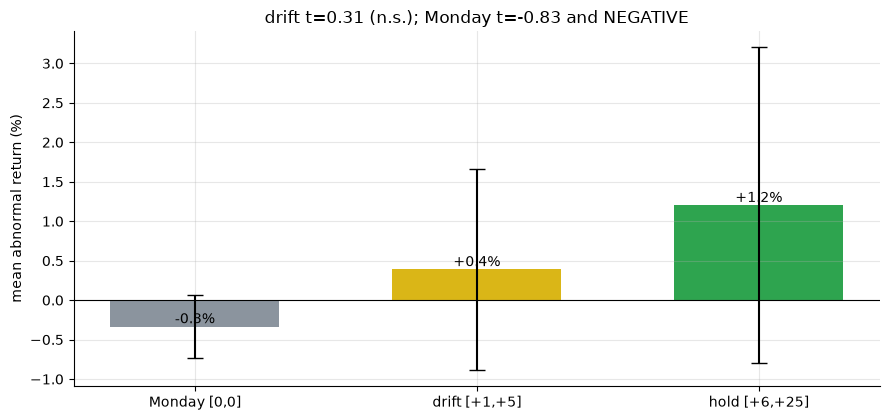

Monday -0.33% (t=-0.83)  drift +0.39% (t=0.31)  hold +1.20% (t=0.60)


In [2]:
if HAVE_REAL:
    M = EV['monday'].values; D = EV['drift'].values; H = EV['hold'].values
    mm, dm, hm = M.mean()*100, D.mean()*100, H.mean()*100
    mse = M.std(ddof=1)/np.sqrt(len(M))*100; dse = D.std(ddof=1)/np.sqrt(len(D))*100
    hse = H.std(ddof=1)/np.sqrt(len(H))*100
    mt, dt, ht = st.welch_t(M), st.welch_t(D), st.welch_t(H)
else:
    mm, dm, hm = R['monday'][0], R['drift'][0], R['hold'][0]
    mt, dt, ht = R['monday'][2], R['drift'][2], R['hold'][2]
    mse, dse, hse = abs(mm/max(abs(mt),1e-9)), abs(dm/max(abs(dt),1e-9)), abs(hm/max(abs(ht),1e-9))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(['Monday [0,0]','drift [+1,+5]','hold [+6,+25]'], [mm, dm, hm], yerr=[mse, dse, hse],
       capsize=6, color=[GREY, AMBER, GREEN], width=.6)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean abnormal return (%)')
ax.set_title(f'drift t={dt:.2f} (n.s.); Monday t={mt:.2f} and NEGATIVE')
for i,v in enumerate([mm,dm,hm]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'Monday {mm:+.2f}% (t={mt:.2f})  drift {dm:+.2f}% (t={dt:.2f})  hold {hm:+.2f}% (t={ht:.2f})')

> 💡 In plain words: the drift is **+0.4%** at **t = 0.31** (not significant); the Monday reaction is **-0.3%** at **t = -0.83** — *negative*, the opposite of a buzz pop; and the hold leg (**+1.2%**, t = 0.60) is a shrug. H₁ is not supported on any leg.

### 4b · The decisive test — a placebo null sized to the event count

Draw 32 random non-event windows 20,000 times; the histogram is the null for the mean drift. The real drift is the green line; the *p*-value is the two-sided tail mass.

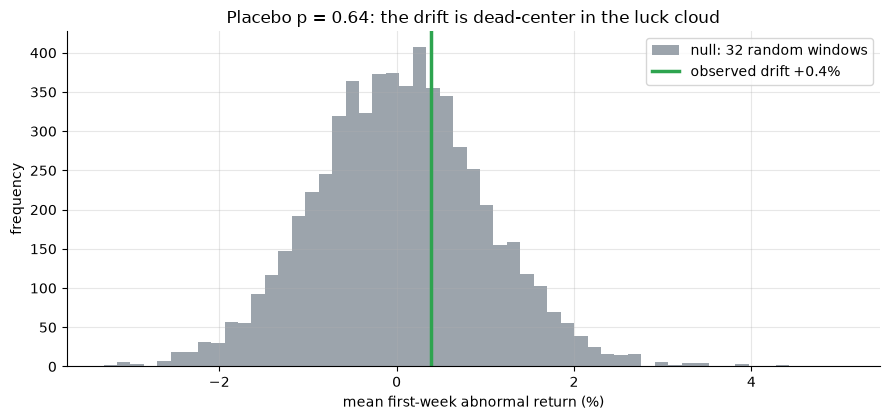

P[|random 32-window mean| >= |drift|] = 0.641  (need <0.05 to call it real)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(B, len(EV), leg='drift', observed=EV['drift'].mean(), n_draws=6000)
    obs = pl['obs']*100; pval = pl['p_value']
    tickers=[c for c in B['prices'].columns if c!='SPY']
    exs=[st._excess_log_returns(B['prices'][t], B['prices']['SPY']) for t in tickers]
    exs=[s for s in exs if len(s)>80]; rng=np.random.default_rng(720)
    draws=[]
    for _ in range(6000):
        vals=[]
        for _ in range(len(EV)):
            s=exs[rng.integers(0,len(exs))]; p0=rng.integers(1,len(s)-7); vals.append(np.expm1(s.iloc[p0:p0+5].sum()))
        draws.append(np.mean(vals))
    draws=np.array(draws)*100
else:
    obs=R['drift'][0]; pval=R['drift'][3]; rng=np.random.default_rng(720); draws=rng.normal(0,1.6,6000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label=f'null: {R["n_priced"]} random windows')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed drift {obs:+.1f}%')
ax.set_xlabel('mean first-week abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the drift is dead-center in the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[|random {R["n_priced"]}-window mean| >= |drift|] = {pval:.3f}  (need <0.05 to call it real)')

> 💡 In plain words: **64%** of random 32-window draws match or beat the drift in magnitude. A real effect would push the green line into the tail; instead it sits mid-cloud. H₁ is **not supported** — the drift is what three-dozen random February weeks look like.

### 4c · By era + robustness — the drift is nowhere and sign-unstable

Split by era and shift the windows. The drift **flips sign** across eras and horizons (2019–21 is *negative*), and the drift *t* never clears 1.2 — the hallmark of noise, not a decaying real effect.

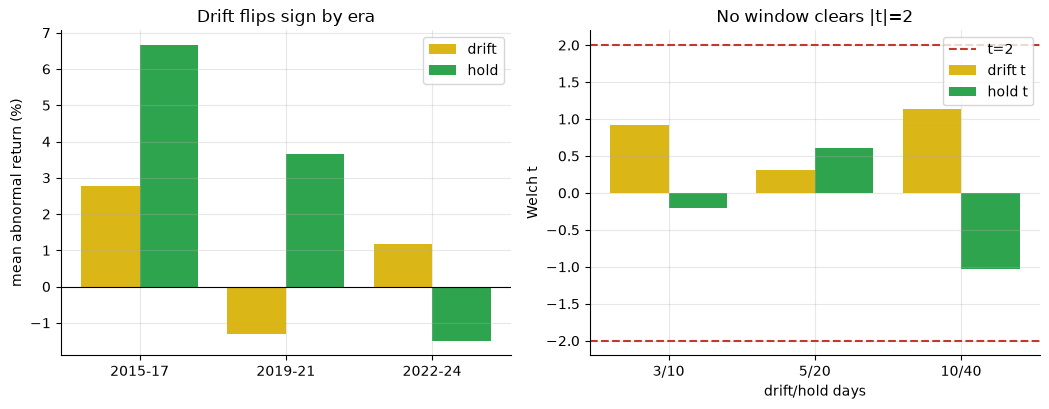

eras: [('2015-17', np.float64(2.8), np.float64(6.7)), ('2019-21', np.float64(-1.3), np.float64(3.7)), ('2022-24', np.float64(1.2), np.float64(-1.5))]


In [4]:
eras = R['eras']
if HAVE_REAL:
    eras = []
    for nm,yrs in [('2015-17',range(2015,2018)),('2019-21',range(2019,2022)),('2022-24',range(2022,2025))]:
        sub = EV[EV['year'].isin(list(yrs))]
        eras.append((nm, len(sub), sub['drift'].mean()*100, sub['hold'].mean()*100))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
names=[e[0] for e in eras]; edr=[e[2] for e in eras]; ehd=[e[3] for e in eras]; xx=np.arange(len(names))
a1.bar(xx-.2, edr, .4, color=AMBER, label='drift'); a1.bar(xx+.2, ehd, .4, color=GREEN, label='hold')
a1.axhline(0, c='k', lw=.8); a1.set_xticks(xx); a1.set_xticklabels(names)
a1.set_ylabel('mean abnormal return (%)'); a1.set_title('Drift flips sign by era'); a1.legend()
if HAVE_REAL:
    rob=[]
    for d_,h_ in [(3,10),(5,20),(10,40)]:
        e2=st.collect_events(B,drift=d_,hold=h_); s2=st.summarize(e2,B,drift=d_,hold=h_,placebo=False)
        rob.append((f'{d_}/{h_}', s2['n'], s2['drift']['mean']*100, s2['drift']['t'], s2['hold']['mean']*100, s2['hold']['t']))
else:
    rob = R['robust']
labs=[r[0] for r in rob]; dts=[r[3] for r in rob]; hts=[r[5] for r in rob]; xx2=np.arange(len(labs))
a2.bar(xx2-.2, dts, .4, color=AMBER, label='drift t'); a2.bar(xx2+.2, hts, .4, color=GREEN, label='hold t')
a2.axhline(2, ls='--', c=RED, label='t=2'); a2.axhline(-2, ls='--', c=RED)
a2.set_xticks(xx2); a2.set_xticklabels(labs); a2.set_ylabel('Welch t'); a2.set_xlabel('drift/hold days')
a2.set_title('No window clears |t|=2'); a2.legend()
plt.tight_layout(); plt.show()
print('eras:', [(e[0], round(e[2],1), round(e[3],1)) for e in eras])

> 💡 In plain words: 2015–17 drifts up, 2019–21 drifts *down*, 2022–24 is flat — a sign that wanders with the sample, not an effect. And across window choices (3/10, 5/20, 10/40) no drift *t* clears 1.2. The result is noise in every choice that could have rescued it.

### 4d · Faithful-engine & power control — we know the truth here

Deterministic event windows with a **planted** post-game drift of size `edge`: with **`edge=0`** the inference must stay flat (a few-dozen noisy events can't fake significance); with a **+10%** planted drift it must light up the drift leg. Both hold — proving the engine is unbiased *and* that this sample size only detects implausibly large effects.

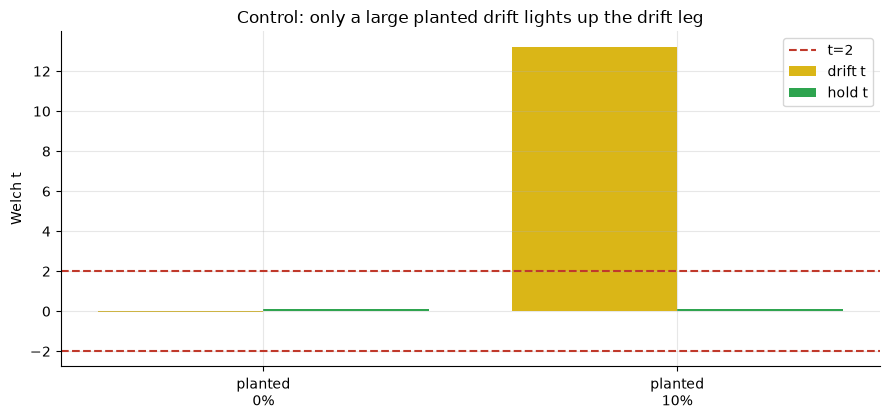

planted   0%: n=32 drift=-0.0%(t=-0.05) hold=+0.2%(t=+0.09)
planted  10%: n=32 drift=+10.5%(t=+13.23) hold=+0.2%(t=+0.09)


In [5]:
res = []
for edge in (0.0, 0.10):
    syn = data.synthetic_ads(n_events=32, edge=edge, seed=726)
    ev = st.collect_events(syn, drift=5, hold=20); s = st.summarize(ev, syn, drift=5, hold=20, placebo=False)
    res.append((edge, s['n'], s['drift']['mean']*100, s['drift']['t'], s['hold']['mean']*100, s['hold']['t']))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labels=[f'planted\n{int(e*100)}%' for e,*_ in res]; xx=np.arange(len(labels))
dts=[r[3] for r in res]; hts=[r[5] for r in res]
ax.bar(xx-.2, dts, .4, color=AMBER, label='drift t'); ax.bar(xx+.2, hts, .4, color=GREEN, label='hold t')
ax.axhline(2, ls='--', c=RED, label='t=2'); ax.axhline(-2, ls='--', c=RED)
ax.set_xticks(xx); ax.set_xticklabels(labels); ax.set_ylabel('Welch t')
ax.set_title('Control: only a large planted drift lights up the drift leg'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,dm,dt,hm,ht in res: print(f'planted {int(e*100):>3}%: n={k} drift={dm:+.1f}%(t={dt:+.2f}) hold={hm:+.1f}%(t={ht:+.2f})')

> 💡 In plain words: with **no** planted edge the control's drift *t* is **-0.05** and hold *t* is **0.09** (both ~0 — no false positive); only the **+10%** plant reaches drift *t* **13.23**. So the machinery is honest, and the real-tape drift *t* of **0.31** is exactly what an *absent or tiny* effect looks like through a 32-event keyhole.

## 5 · The verdict

- **Signal `NONE`** — drift **+0.4%** at Welch **t = 0.31** / placebo **p = 0.64**, win-rate **47%** (< 50%); Monday reaction **-0.3%** (t = -0.83, *negative*). Fehle-Tsyplakov-Zdorovtsov (2005) found the effect on a 2000–04 sample, but this modern tape is indistinguishable from noise ⇒ NONE, not WEAK. **Survivorship** named on this axis: the advertisers that went bust delisted, biasing the drift *up*.
- **Tradability `MIRAGE`** — the long-the-advertisers basket is **+0.4% gross**, **+0.2% net** of 2 large-cap crossings over 5 days — a rounding error inside its own SE, indistinguishable from a week of February beta.
- **Big-ad signal? `NOT SUPPORTED`** — the legend is a much-cited 2005 result plus a memorable sock puppet; across a representative modern survivor table the post-game drift is a coin-flip and the day-one move is negative.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* drift have to be for a $k$-event study to detect it at $t=2$? At $k\approx 32$ you'd need a drift several times the one observed; the real signal lives far below the detection floor — and the basket is a rounding error on top.

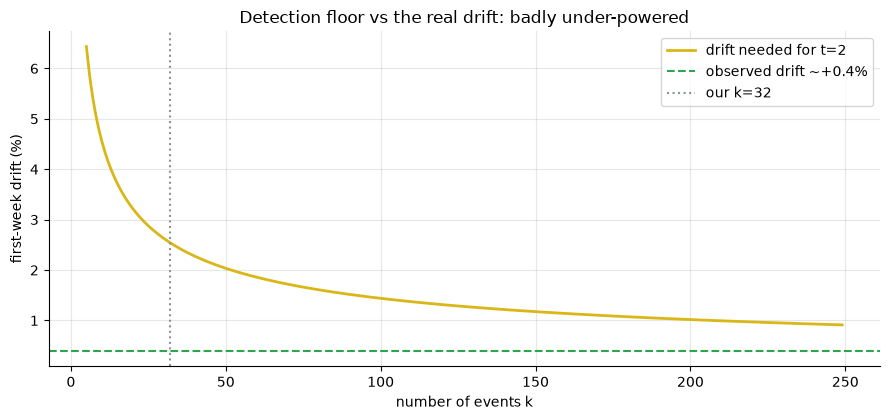

at k=32 you need ~2.5% drift for t=2; observed ~+0.4% -> under-powered


In [6]:
if HAVE_REAL:
    sd = EV['drift'].std(ddof=1); obs = EV['drift'].mean()
else:
    sd = R['drift_std']; obs = R['drift'][0]/100
ks = np.arange(5, 250)
min_det = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_det*100, c=AMBER, lw=2, label='drift needed for t=2')
ax.axhline(obs*100, c=GREEN, ls='--', label=f'observed drift ~{obs*100:+.1f}%')
ax.axvline(R['n_priced'], c=GREY, ls=':', label=f"our k={R['n_priced']}")
ax.set_xlabel('number of events k'); ax.set_ylabel('first-week drift (%)')
ax.set_title('Detection floor vs the real drift: badly under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_priced'])*100
print(f'at k={R["n_priced"]} you need ~{need:.1f}% drift for t=2; observed ~{obs*100:+.1f}% -> under-powered')

> 💡 In plain words: the amber curve is the **minimum detectable drift**; the green line is what we see. They don't meet until $k$ is many times larger than the Super Bowl calendar will ever deliver (one game a year, a couple-dozen listed advertisers) — and even a *real* drift this small wouldn't clear large-cap costs. There is no sizing, threshold, or cost assumption that manufactures an edge from ~32 events whose mean is a coin-flip whisper. The rarity that makes the legend fun (one big night a year) is exactly what makes it untestable and untradable.

## 7 · Going further

- **The adjacent attention effect.** [Study 389 — Name-Change-Effect](../389-name-change-effect/): does renaming toward the hot theme (`.com`/`Blockchain`/`AI`) pay? Same family (an attention grab, not a fundamental), same small-sample / survivorship pathology.
- **The anecdote trap, formalised.** [Study 343 — Data-Mining-Roulette](../343-data-mining-roulette/) on how loud cases manufacture spurious 'laws'.
- **Add the corpses.** Reconstruct the delisted advertisers (Pets.com, Computer.com, Kozmo.com) from a survivorship-free CRSP feed; the drift wouldn't grow — those names went to a −100% bankruptcy, informative about the *story*, not a tradable leg. And re-run the Fehle-Tsyplakov-Zdorovtsov (2005) window on 2000–04 to see the effect that has since faded.

*The reproducible core is offline and deterministic; the advertiser table is hardcoded and the priced tape is survivor-biased (named). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*